# Семинар 3: работа с таблицами в pandas

## Вступление
Сегодня мы начнём работать с табличными данными в питоне, и в этом нам поможет библиотека pandas. Pandas — это самый популярный инструмент для работы с данными. Цель семинара — познакомить вас с основными конструкциями pandas и научить им пользоваться.

Почему pandas удобный?
1.	Удобное представление таблиц и куча готовых методов, как работать с этими таблицами
2.	Простота использования
3.	Наличие встроенных визуализаций
4.	Наличие всех функций из excel (и даже больше)
5.	Универсальность инструмента, можно читать почти все табличные типы данных
6.	Хорошо подходит для экспериментов с данными

А почему он неудобный?
1.	Медленный
2.	Чаще всего нельзя использовать в проде из-за скорости
3.	Иногда сложно интерпретировать код, написанный на pandas

### План семинара
1. Работаем с датасетом оценок студентов
2. Работаем с датасетом пассажиров Титаника

### Дополнительные материалы

[Pandas Cheat Sheet](https://github.com/pandas-dev/pandas/blob/master/doc/cheatsheet/Pandas_Cheat_Sheet.pdf)

[10 Minutes To Pandas](https://pandas.pydata.org/pandas-docs/stable/10min.html)

[Pandas CookBook](https://pandas.pydata.org/pandas-docs/stable/cookbook.html#cookbook)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 1. Работаем с датасетом оценок студентов

Pandas предоставляет нам много различных инструментов работы с табличными данными. Главные из них — это: класс таблицы `pandas.core.frame.DataFrame` и его методы; класс серии данных (например, столбец таблицы) `pandas.core.series.Series` и его методы; и различные функции библиотеки. 

Начнём с подгрузки таблицы из файла и посмотрим на методы класса `DataFrame`.

In [ ]:
df = pd.read_csv("grades.csv", sep=",", index_col=0)
type(df)

In [ ]:
# размер таблицы
df.shape

In [ ]:
# вывести начало таблицы
df.head(5)

In [ ]:
# вывести конец таблицы
df.tail()

In [ ]:
# выбрать случайные строки
df.sample(n=5)

In [ ]:
# выбрать случайные строки 2
df.sample(frac=0.1)

Добавим работу со столбцами: датафрейм можно индексировать квадратными скобками с названиями столбцов. Столбец будет экземпляром класса `pandas.core.series.Series`.

In [ ]:
col0 = df["0"]
col0

In [ ]:
type(col0)

In [ ]:
# выбрать 5 строк с наибольшими значениями в столбцах '3', '4'
df.nlargest(n=7, columns=["3", "4"])

In [ ]:
# подсчитать количество уникальных значений в столбце 3
df["3"].nunique()

In [ ]:
# подсчитать, сколько раз встретилось в столбце '3' каждое уникальное значение
df["3"].value_counts()

Доступ к столбцу можно получить не только через квадратные скобки, но и через точку, по аналогии с атрибутом класса.

In [ ]:
df["hash"]

In [ ]:
df.hash

А вот доступ к строкам можно получить при помощи `.iloc` и `loc`. Внешне они выглядят одинаково, но отличаются в деталях: первый индексирует по номеру строки, а второй — по индексирующему столбцу. Мы вернёмся к этому ниже, когда будет говорить про данные пассажиров Титаника. Обратите внимание, что такая индексация возвращает новый объект класса `DataFrame`.

In [ ]:
df.iloc[:5]

In [ ]:
# склеить две таблицы по строкам
df1 = df.iloc[:5]
df2 = df.iloc[10:15]
pd.concat([df1, df2])

In [ ]:
# склеить две таблицы по столбцам
df1 = df[["hash", "1"]]
df2 = df[["3", "4"]]
pd.concat([df1, df2], axis=1).head()

Метод `DataFrame.merge` объединяет таблицы по переданному столбцу (аналог SQL: JOIN).

In [ ]:
# таблица с оценками
df_grades = pd.read_csv("grades.csv", index_col=0)
df_grades.head()

In [ ]:
df_hashes = pd.read_csv("hashes.csv")
df_hashes.head()

Не для всех студентов известны оценки!

In [ ]:
df_grades.hash.nunique(), df_hashes.hash.nunique()

In [ ]:
# присоединить подходящие строки из df_grades к df_hashes
df = pd.merge(df_hashes, df_grades, on="hash", how="left")
print(df.shape)
df.head(10)

In [ ]:
# присоединить подходящие строки из df_hashes к df_grades
df = pd.merge(df_hashes, df_grades, on="hash", how="right")
print(df.shape)
df.head(10)

In [ ]:
# пересечение таблиц
# в данном случае эквивалентно 'right', т.к. в df_grades нет таких хэшей, которые отсутствуют в df_hashes
df = pd.merge(df_hashes, df_grades, on="hash", how="inner")
print(df.shape)
df.head(10)

In [ ]:
# объединение таблиц
# в данном случае эквивалентно 'left', т.к. в df_grades нет таких хэшей, которые отсутствуют в df_hashes
df = pd.merge(df_hashes, df_grades, on="hash", how="outer")
print(df.shape)
df.head(10)

In [ ]:
# выбрать из таблицы хэшей только те строки, в которых хэш есть в таблице оценок
# т.е. отобрать тех студентов, которые писали контрольную и были оценены
df = df_hashes[df_hashes.hash.isin(df_grades.hash)]
print(df.shape)
df.head()

In [ ]:
# сколько человек из каждой группы были оценены?
df.Группа.value_counts()

In [ ]:
type(df)

In [ ]:
type(df["Группа"])

Метод `DataFrame.groupby` делает группировку строк по значениям в каком-то столбце, чтобы мы могли их усреднить/просуммировать/etc. Например, если бы у нас была таблица вида [студент - предмет - оценка], то мы могли бы сгруппировать строки по столбцу предмета и посчитать по каждому предмету среднюю оценку.

In [47]:
dfg = df_grades
dfg = dfg.drop(columns=['hash'])

dfg.head()

,0,1,2,3,4,5,6,7,8
0,0.8,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
1,0.2,0.2,0.9,0.7,0.0,0.0,0.0,0.0,0.0
2,0.8,1.0,1.0,1.0,1.0,0.0,0.5,0.0,0.0
3,0.0,0.0,0.8,1.0,0.5,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [48]:
# сгруппировать строки по столбцу '1'
gr = dfg.groupby(by="1")
gr

In [51]:
gr.head()

,0,1,2,3,4,5,6,7,8
0,0.8,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
1,0.2,0.2,0.9,0.7,0.0,0.0,0.0,0.0,0.0
2,0.8,1.0,1.0,1.0,1.0,0.0,0.5,0.0,0.0
3,0.0,0.0,0.8,1.0,0.5,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.5,0.8,0.5,0.5,0.0,0.0,0.0,0.0,0.0
6,0.9,1.0,1.0,1.0,0.8,0.0,0.5,0.0,0.7
7,0.8,0.0,1.0,0.9,1.0,1.0,0.5,0.0,0.0
8,0.0,0.9,0.0,0.5,0.5,0.0,0.0,0.0,0.0
9,0.8,1.0,0.0,0.2,0.5,0.2,0.0,0.0,0.2


In [49]:
df_grades["1"].nunique()

8

In [ ]:
# какая средняя оценка (и ее дисперсия) за другие задачи у студентов, получивших конкретную оценку по задаче '1'?

In [50]:
gr.mean()

,0,2,3,4,5,6,7,8
1,,,,,,,,
0.0,0.133333,0.466667,0.483333,0.250000,0.166667,0.083333,0.000000,0.000000
0.2,0.300000,0.933333,0.800000,0.166667,0.066667,0.166667,0.000000,0.066667
0.5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0.6,0.000000,1.000000,1.000000,1.000000,0.500000,0.000000,0.000000,0.700000
0.7,0.000000,1.000000,1.000000,0.000000,0.250000,0.000000,0.000000,0.000000
0.8,0.250000,0.250000,0.600000,0.250000,0.000000,0.000000,0.000000,0.000000
0.9,0.500000,0.250000,0.500000,0.625000,0.125000,0.000000,0.250000,0.150000
1.0,0.594737,0.789474,0.773684,0.463158,0.252632,0.289474,0.094737,0.442105


In [52]:
# дисперсия
gr.var()

,0,2,3,4,5,6,7,8
1,,,,,,,,
0.0,0.106667,0.266667,0.281667,0.175000,0.166667,0.041667,0.000000,0.000000
0.2,0.030000,0.003333,0.030000,0.083333,0.013333,0.083333,0.000000,0.013333
0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.7,0.000000,0.000000,0.000000,0.000000,0.125000,0.000000,0.000000,0.000000
0.8,0.125000,0.125000,0.020000,0.125000,0.000000,0.000000,0.000000,0.000000
0.9,0.226667,0.250000,0.166667,0.062500,0.062500,0.000000,0.250000,0.090000
1.0,0.133860,0.140994,0.155380,0.086901,0.135965,0.064327,0.080526,0.108129


In [ ]:
# откуда взялись NaN?

In [53]:
gr.get_group(0.2)

,0,1,2,3,4,5,6,7,8
1,0.2,0.2,0.9,0.7,0.0,0.0,0.0,0.0,0.0
16,0.2,0.2,0.9,0.7,0.0,0.0,0.0,0.0,0.0
29,0.5,0.2,1.0,1.0,0.5,0.2,0.5,0.0,0.2


## 2. Работаем с датасетом пассажиров Титаника

Каждая строчка наборов данных содержит следующие поля:

- Pclass — класс пассажира (1 — высший, 2 — средний, 3 — низший);

- Name — имя;

- Sex — пол;

- Age — возраст;

- SibSp — количество братьев, сестер, сводных братьев, сводных сестер, супругов на борту Титаника;

- Parch — количество родителей, детей (в том числе приемных) на борту Титаника;

- Ticket — номер билета;

- Fare — плата за проезд;

- Cabin — каюта;

- Embarked — порт посадки (C — Шербур; Q — Квинстаун; S — Саутгемптон)

- Survived - пассажир выжил или нет.

В поле Age приводится количество полных лет. Для детей меньше 1 года — дробное. Если возраст не известен точно, то указано примерное значение в формате xx.5.

In [54]:
df = pd.read_csv("titanic_train.csv", sep=",")

In [55]:
# типы данных
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [56]:
# сравним, сколько места занимает столбец
df["SibSp"].astype("int64").memory_usage()

7260

In [57]:
df["SibSp"].astype("int8").memory_usage()

1023

In [58]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Для первичного анализа полезно посмотреть на базовые статистики численных переменных. Для этого есть готовый метод:

In [59]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [60]:
df.describe(include='object')

C:\Users\mg\AppData\Local\Temp\ipykernel_1392\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


Также полезно проверить, какие переменные коррелированы больше, а какие — меньше.

In [62]:
df.corr(method='pearson')

ValueError: could not convert string to float: 'Braund, Mr. Owen Harris'

In [63]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [64]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [65]:
df.index

RangeIndex(start=0, stop=891, step=1)

In [66]:
Y = df["Survived"]
Y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [67]:
df[["Survived", "Age"]].head()

,Survived,Age
0,0,22.0
1,1,38.0
2,1,26.0
3,1,35.0
4,0,35.0


In [68]:
# удаление данных одного из столбцов
X = df[df.columns.drop("Survived")]

In [69]:
X = df.drop("Survived", axis=1)  # same thing as previous cell

In [70]:
df.shape, X.shape, Y.shape

((891, 12), (891, 11), (891,))

Обещанная индексация! Давайте сперва проиндексируем таблицу двумя способами через `iloc` и `loc`, а затем изменим индексирующий столбец и посмотри на разницу.

In [71]:
X.iloc[[5, 8, 10]]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
8,9,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
10,11,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S


In [72]:
X.loc[[5, 8, 10]]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
8,9,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
10,11,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S


In [73]:
# Меняем индексацию!
df_new = df.set_index("Name")
df_new.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Name,,,,,,,,,,,
"Braund, Mr. Owen Harris",1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
"Heikkinen, Miss. Laina",3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
"Futrelle, Mrs. Jacques Heath (Lily May Peel)",4,1,1,female,35.0,1,0,113803,53.1000,C123,S
"Allen, Mr. William Henry",5,0,3,male,35.0,0,0,373450,8.0500,NaN,S


In [74]:
df_new.loc["Braund, Mr. Owen Harris"]

PassengerId            1
Survived               0
Pclass                 3
Sex                 male
Age                 22.0
SibSp                  1
Parch                  0
Ticket         A/5 21171
Fare                7.25
Cabin                NaN
Embarked               S
Name: Braund, Mr. Owen Harris, dtype: object

In [75]:
df_new.iloc["Braund, Mr. Owen Harris"]

TypeError: Cannot index by location index with a non-integer key

### Анализ данных

In [76]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [77]:
set(df["Sex"])

{'female', 'male'}

In [78]:
len(set(df["Name"]))

891

In [79]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

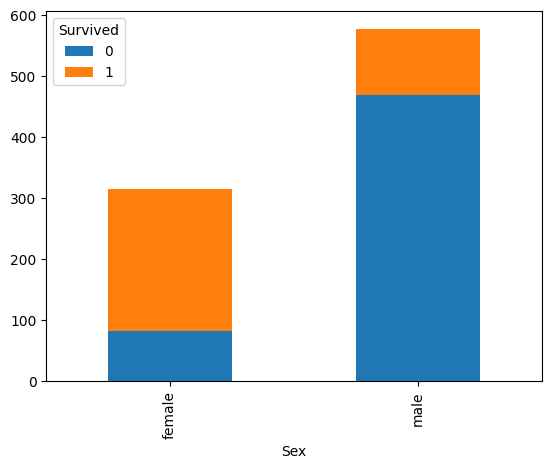

In [80]:
df.pivot_table("PassengerId", "Sex", "Survived", "count").plot(kind="bar", stacked=True);
# Какой вывод из полученных гистограмм?

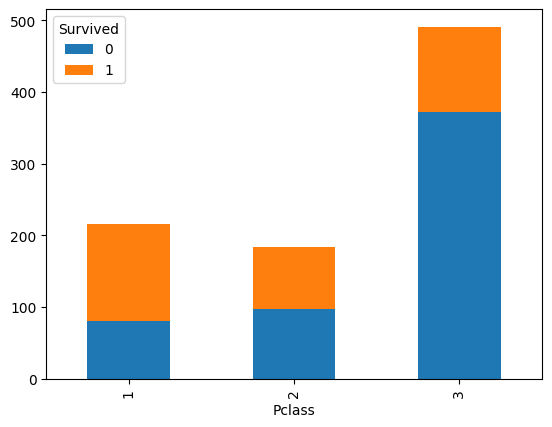

In [81]:
df.pivot_table("PassengerId", "Pclass", "Survived", "count").plot(
    kind="bar", stacked=True
);
# Какой вывод из полученных гистограмм?

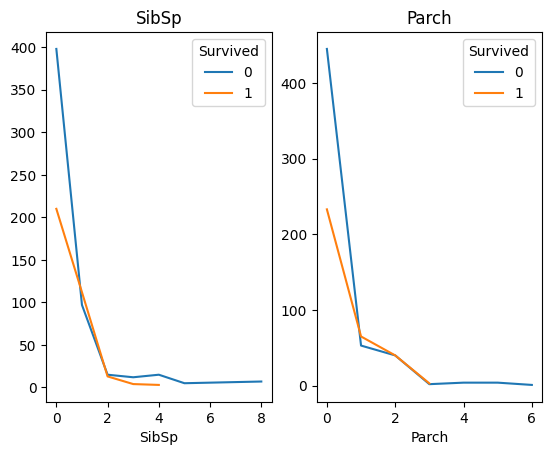

In [82]:
fig, axes = plt.subplots(ncols=2)
df.pivot_table("PassengerId", ["SibSp"], "Survived", "count").plot(
    ax=axes[0], title="SibSp"
)
df.pivot_table("PassengerId", ["Parch"], "Survived", "count").plot(
    ax=axes[1], title="Parch"
);

# Какой вывод из полученных графиков?

<Axes: xlabel='PassengerId'>

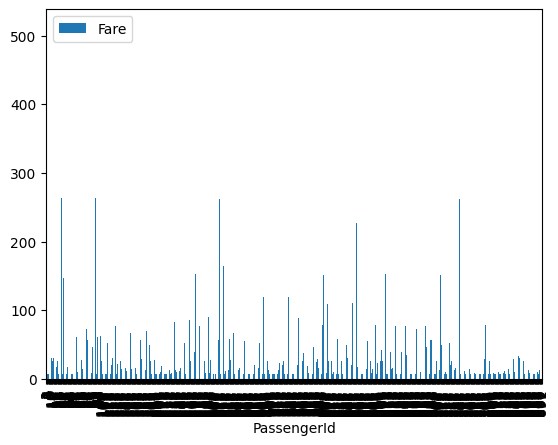

In [83]:
df.plot(x="PassengerId", y="Fare", kind="bar")

### Обработка и преобразование данных

In [84]:
df.head(7)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S


In [85]:
# преобразуем текстовый признак "Пол" в числовые значения
df["DecodedSex"] = df["Sex"].map({"male": 1, "female": -1, "unknown": 0})
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,DecodedSex
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,-1


In [86]:
# добавим еще одну характеристику для каждого объекта датасета
def fun(age):
    return age / 100


df["NewAge"] = df["Age"].apply(fun)
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,DecodedSex,NewAge
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,0.22
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,-1,0.38


In [87]:
# то же самое можно сделать с помощью лямбда функции
df["NewAge"] = df["Age"].apply(lambda age: age / 100)
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,DecodedSex,NewAge
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,0.22
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,-1,0.38


In [88]:
df["NewAge"] = df["Age"] / 100
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,DecodedSex,NewAge
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,0.22
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,-1,0.38


**Важно!** Pandas, как и NumPy, является лишь обёрткой на питоне для вычислительно эффективных операций над большими данными. Любое использование циклов в pandas приводит к неэффективности кода. Методы `.apply` и `.map` **медленные**, потому что внутри в цикле применяют питоновскую функцию к элементам таблицы. Старайтесь всегда использовать более эффективные реализации (например, арифметические операторы над столбцами) и прибегать к `.apply` и `.map` только в крайнем случае!

In [89]:
%%timeit
df["NewAge"] = df["Age"].apply(lambda age: age / 100)

400 μs ± 14.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [90]:
%%timeit
df["NewAge"] = df["Age"] / 100

134 μs ± 2.95 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [91]:
# выделим фамилию из данных
df["Surname"] = df["Name"].apply(lambda name: name.split(",")[0])  # option1
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,DecodedSex,NewAge,Surname
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,0.22,Braund
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,-1,0.38,Cumings
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,-1,0.26,Heikkinen
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,-1,0.35,Futrelle
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,0.35,Allen


In [92]:
df.shape

(891, 15)

In [93]:
df.Surname.nunique()

667

In [94]:
df["Surname"] = df["Name"].apply(lambda name: name[: name.find(",")])  # option 2

In [95]:
df["Surname"].value_counts().head()

Surname
Andersson    9
Sage         7
Johnson      6
Panula       6
Goodwin      6
Name: count, dtype: int64

In [96]:
df.values  # df -> numpy.array

array([[1, 0, 3, ..., 1, 0.22, 'Braund'],
       [2, 1, 1, ..., -1, 0.38, 'Cumings'],
       [3, 1, 3, ..., -1, 0.26, 'Heikkinen'],
       ...,
       [889, 0, 3, ..., -1, nan, 'Johnston'],
       [890, 1, 1, ..., 1, 0.26, 'Behr'],
       [891, 0, 3, ..., 1, 0.32, 'Dooley']], shape=(891, 15), dtype=object)

In [97]:
# Исследуем возраст пассажиров Титаника
df.groupby("Sex")["Age"].mean()

Sex
female    27.915709
male      30.726645
Name: Age, dtype: float64

In [98]:
# опять же, обращаем внимание на эффективное использование pandas
%timeit df.groupby("Sex")["Age"].mean()

706 μs ± 12.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [99]:
%timeit df.groupby("Sex")["Age"].apply(np.mean)

1.13 ms ± 24 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [100]:
df.groupby("Sex")["Age"].apply(lambda ages: np.mean(ages) ** 2)

Sex
female    779.286798
male      944.126688
Name: Age, dtype: float64

In [101]:
df.groupby("Survived")["Age"].apply(np.mean)

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

In [102]:
# группировка по нескольким столбцам и агрегация нескольких полей сразу
df.groupby(["Sex", "Pclass"]).agg(avg=("Age", "mean"), avg_surv=("Survived", "mean"))

avg  avg_surv
Sex    Pclass                     
female 1       34.611765  0.968085
       2       28.722973  0.921053
       3       21.750000  0.500000
male   1       41.281386  0.368852
       2       30.740707  0.157407
       3       26.507589  0.135447

In [103]:
# .mean -> .count
# В скольких семьях было больше трёх человек?
np.sum(df.groupby("Surname")["Name"].count() > 3)

np.int64(22)

In [104]:
# Сколько семей, в которых минимальный возраст меньше 10 лет?
np.sum(df.groupby("Surname")["Age"].apply(min) < 10)

np.int64(38)

Снова про индексацию! Как и в numpy, можно индексировать значения булевыми масками.

In [105]:
((df["Age"] > 10) & (df["Age"] < 20)).value_counts()

Age
False    791
True     100
Name: count, dtype: int64

In [106]:
# пассажиры, удовлетворяющие условию
df.loc[(df["Age"] > 10) & (df["Age"] < 20)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,DecodedSex,NewAge,Surname
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,-1,0.14,Nasser
14,15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,NaN,S,-1,0.14,Vestrom
22,23,1,3,"McGowan, Miss. Anna ""Annie""",female,15.0,0,0,330923,8.0292,NaN,Q,-1,0.15,McGowan
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S,1,0.19,Fortune
38,39,0,3,"Vander Planke, Miss. Augusta Maria",female,18.0,2,0,345764,18.0000,NaN,S,-1,0.18,Vander Planke
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853,854,1,1,"Lines, Miss. Mary Conover",female,16.0,0,1,PC 17592,39.4000,D28,S,-1,0.16,Lines
855,856,1,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S,-1,0.18,Aks
875,876,1,3,"Najib, Miss. Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C,-1,0.15,Najib
877,878,0,3,"Petroff, Mr. Nedelio",male,19.0,0,0,349212,7.8958,NaN,S,1,0.19,Petroff
